In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
# create a model class that inherits nn.Module

class Model(nn.Module):

    # Input layer (4 features) -> hidden layer1 (number of neurons) -> hidden layer2 etc
    # output to 3 potential classes

    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() # insantiate nn.module
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)

        return x

In [4]:
torch.manual_seed(41)

model = Model()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [7]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [8]:
print(my_df.groupby('species').max())

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa               5.8          4.4           1.9          0.6
versicolor           7.0          3.4           5.1          1.8
virginica            7.9          3.8           6.9          2.5


In [9]:
#change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [10]:
my_df.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
0.0,5.006,3.418,1.464,0.244
1.0,5.936,2.770,4.260,1.326
2.0,6.588,2.974,5.552,2.026


In [11]:
# Train test split

X = my_df.drop('species', axis=1)
y = my_df['species']

In [12]:
# convert them to np arrays

X = X.values
y = y.values

In [13]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [14]:
y = y.astype(np.int64)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
#train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)



In [17]:
y_train

array([1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 2, 2, 0, 2, 1, 0, 1, 2, 1,
       2, 0, 0, 2, 2, 0, 1, 0, 0, 1, 0, 1, 2, 0, 1, 1, 2, 0, 1, 1, 0, 2,
       1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 2, 1, 0,
       0, 2, 2, 2, 1, 1, 2, 0, 1, 2, 1, 1, 0, 1, 0, 1, 0, 1, 2, 2, 2, 0,
       0, 0, 0, 2, 0, 0, 1, 2, 0, 2, 0, 1, 2, 1, 0, 2, 0, 1, 0, 2, 1, 1,
       2, 1, 1, 2, 2, 0, 1, 1, 1, 2])

In [18]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [19]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [20]:
# set criterion for measuring error

criterion = nn.CrossEntropyLoss()

# Adam optimizer

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [21]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [22]:
# Training
epochs = 100
losses = []
for i in range(epochs):
    y_pred = model.forward(X_train) #get predicted results

    loss = criterion(y_pred, y_train)

    losses.append(loss.item())

    if i % 10 == 0:
        print(f'epoch: {i}, loss: {loss}')

    # back propgation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch: 0, loss: 1.1251550912857056
epoch: 10, loss: 1.0096259117126465
epoch: 20, loss: 0.8157405853271484
epoch: 30, loss: 0.585706353187561
epoch: 40, loss: 0.3999636471271515
epoch: 50, loss: 0.26768797636032104
epoch: 60, loss: 0.17942363023757935
epoch: 70, loss: 0.12151690572500229
epoch: 80, loss: 0.0860118567943573
epoch: 90, loss: 0.06520850956439972


In [23]:
print(type(loss))

<class 'torch.Tensor'>


Text(0.5, 0, 'epoch')

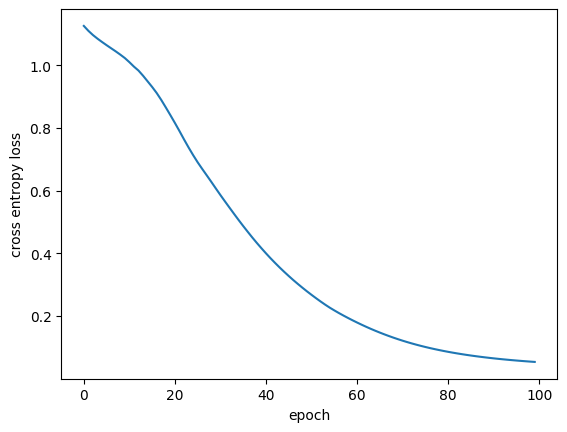

In [24]:
# graphin the loss
plt.plot(range(epochs), losses)
plt.ylabel('cross entropy loss')
plt.xlabel('epoch')

In [25]:
# evaluate model on training data
with torch.no_grad():
    y_eval = model.forward(X_test)
    loss = criterion(y_eval, y_test)
    

In [26]:
loss

tensor(0.1315)

In [27]:
X_test

tensor([[6.0000, 2.2000, 5.0000, 1.5000],
        [6.4000, 2.8000, 5.6000, 2.1000],
        [7.7000, 3.0000, 6.1000, 2.3000],
        [6.1000, 3.0000, 4.6000, 1.4000],
        [6.8000, 3.0000, 5.5000, 2.1000],
        [6.1000, 2.8000, 4.0000, 1.3000],
        [6.3000, 2.7000, 4.9000, 1.8000],
        [6.0000, 3.4000, 4.5000, 1.6000],
        [6.5000, 3.0000, 5.2000, 2.0000],
        [6.8000, 3.2000, 5.9000, 2.3000],
        [6.1000, 3.0000, 4.9000, 1.8000],
        [5.1000, 3.4000, 1.5000, 0.2000],
        [4.4000, 3.0000, 1.3000, 0.2000],
        [5.0000, 2.3000, 3.3000, 1.0000],
        [5.1000, 3.3000, 1.7000, 0.5000],
        [6.3000, 2.8000, 5.1000, 1.5000],
        [4.8000, 3.1000, 1.6000, 0.2000],
        [6.0000, 2.7000, 5.1000, 1.6000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [4.5000, 2.3000, 1.3000, 0.3000],
        [5.5000, 2.4000, 3.7000, 1.0000],
        [6.9000, 3.2000, 5.7000, 2.3000],
        [5.0000, 3.5000, 1.6000, 0.6000],
        [4.7000, 3.2000, 1.3000, 0

In [29]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        print(f'{i + 1} {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

        if y_val.argmax().item() == y_test[i]:
            correct += 1

    print(f"got: {correct} out {i + 1}")

1 tensor([-5.8760,  4.4628,  6.5124]) 	 2 	 2
2 tensor([-7.5436,  4.1670,  9.7255]) 	 2 	 2
3 tensor([-8.4504,  5.1271, 10.1987]) 	 2 	 2
4 tensor([-4.3398,  5.6267,  2.5608]) 	 1 	 1
5 tensor([-7.1825,  4.8754,  8.2992]) 	 2 	 2
6 tensor([-3.3974,  5.3463,  1.2803]) 	 1 	 1
7 tensor([-5.9231,  4.9822,  5.9997]) 	 2 	 2
8 tensor([-4.2881,  5.7003,  2.3889]) 	 1 	 1
9 tensor([-6.5356,  4.9257,  7.1260]) 	 2 	 2
10 tensor([-8.0509,  4.4129, 10.3286]) 	 2 	 2
11 tensor([-5.6762,  4.9500,  5.6215]) 	 2 	 2
12 tensor([ 4.5662, -2.2476, -2.8911]) 	 0 	 0
13 tensor([ 4.2571, -1.9967, -2.7330]) 	 0 	 0
14 tensor([-2.1108,  4.0515,  0.5799]) 	 1 	 1
15 tensor([ 3.4575, -1.2098, -2.3514]) 	 0 	 0
16 tensor([-5.4724,  5.1165,  5.0934]) 	 2 	 1
17 tensor([ 4.0557, -1.7949, -2.6492]) 	 0 	 0
18 tensor([-5.8075,  4.6053,  6.2458]) 	 1 	 2
19 tensor([ 4.4343, -2.1392, -2.8242]) 	 0 	 0
20 tensor([ 3.4527, -1.2514, -2.3660]) 	 0 	 0
21 tensor([-2.6189,  4.5619,  0.8574]) 	 1 	 1
22 tensor([-7.7412,  4

In [30]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.7])

In [33]:
with torch.no_grad():
    print(model.forward(new_iris))

tensor([ 3.4374, -1.2075, -2.3490])


In [34]:
# Save NN model
torch.save(model.state_dict(), 'iris_recognition_model.pt')

In [35]:
# load saved model
new_model = Model()
new_model.load_state_dict(torch.load('iris_Recognition_model.pt'))

<All keys matched successfully>

In [36]:
model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)